In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from robusta_hmf import Robusta
import time
#%matplotlib widget

In [51]:
#define constants
c = 299792.458 # km/s
LN10 = np.log(10.)
MAX_IVAR = 2.5e3
MIN_IVAR = 0.1
H_ALPHA, H_BETA = 6564.614, 4862.721 #Reference: from classic.sdss.org
HE_I_6680 = 6680 #Reference: Johanna brain
HE_I_4026 = 4026
HE_I_4471 = 4471
HE_I_4922 = 4922
HE_I_4713 = 4713
HE_II_4686 = 4686 #Reference: Johanna brain
HE_II_4542 = 4542
HE_II_4200 = 4200

HE_I = 6680
HE_II = 4686

lines_balmer = [H_ALPHA, H_BETA]
lines_HE_I = [HE_I_6680, HE_I_4026, HE_I_4471, HE_I_4922, HE_I_4713]
lines_HE_II = [HE_II_4686, HE_II_4542, HE_II_4200]


#get more to check from Johanna
lines = [H_ALPHA, H_BETA, HE_I, HE_II]
line_labels = ["Halpha", "Hbeta", "HeI", "HeII"]
moment_names = ["EW", "centroid", "variance", "skew", "m4"]

H_delta_lnlam_line = 1000 / c 
H_delta_loglam_line = H_delta_lnlam_line / LN10 
HE_delta_lnlam_line = 500 / c
HE_delta_loglam_line = HE_delta_lnlam_line / LN10
log_H_ALPHA, log_H_BETA, log_HE_I, log_HE_II = np.log10(H_ALPHA), np.log10(H_BETA), np.log10(HE_I), np.log10(HE_II)

half_wids = [H_delta_loglam_line, H_delta_loglam_line, HE_delta_loglam_line, HE_delta_loglam_line] 

In [3]:
#load stellar parameters
DATESTR = "2026-07-20"

stars = pd.read_parquet(f"parent_stars10k_{DATESTR}.parquet")
print("num of stars in parquet:", stars.shape[0])

spectra_temp = pd.read_parquet(f"spectra_{DATESTR}_table.parquet")
print("num of spectra in parquet:", stars.shape[0])

print(stars.shape)

num of stars in parquet: 114190
num of spectra in parquet: 114190
(114190, 394)


In [4]:
print("spectra before:", spectra_temp.shape)
spectra = spectra_temp.join(stars[["GAIA_ID", "Teff_fit", "NANA_HASH"]].set_index("GAIA_ID"), on = "GAIA_ID", rsuffix = "_stars", how = "left", validate = "m:1")
print("spectra after:", spectra.shape)

spectra before: (24713, 846)
spectra after: (24713, 848)


In [5]:
print(spectra.columns.to_list())

['FIELD', 'MJD', 'OBS', 'MJD_FINAL', 'MJD_LIST', 'TAI_LIST', 'RUN2D', 'RUN1D', 'DESIGNS', 'CONFIGS', 'NEXP', 'EXPTIME', 'TARGET_INDEX', 'FIBERID_LIST', 'SPEC_FILE', 'PROGRAMNAME', 'SURVEY', 'CADENCE', 'FIRSTCARTON', 'CARTON_TO_TARGET_PK', 'OBJTYPE', 'TOO', 'TOO_ID', 'CATALOGID', 'CATALOGID_V0', 'CATALOGID_V0P5', 'CATALOGID_V1', 'SDSS_ID', 'SPECOBJID', 'OPTICAL_PROV', 'GAIA_G_MAG', 'GRI_GAIA_TRANSFORM', 'BP_MAG', 'RP_MAG', 'GAIA_ID', 'WISE_MAG_1', 'WISE_MAG_2', 'WISE_MAG_3', 'WISE_MAG_4', 'TWOMASS_MAG_1', 'TWOMASS_MAG_2', 'TWOMASS_MAG_3', 'GUVCAT_MAG_1', 'GUVCAT_MAG_2', 'EBV', 'EBV_TYPE', 'FIBER_RA', 'FIBER_DEC', 'PLUG_RA', 'PLUG_DEC', 'RACAT', 'DECCAT', 'COORD_EPOCH', 'PMRA', 'PMDEC', 'PARALLAX', 'RA_LIST', 'DEC_LIST', 'DELTA_RA_LIST', 'DELTA_DEC_LIST', 'FIBER_OFFSET', 'XFOCAL', 'YFOCAL', 'ZOFFSET', 'LAMBDA_EFF', 'BLUEFIBER', 'HEALPIX', 'HEALPIXGRP', 'HEALPIX_PATH', 'FIELDQUALITY', 'EXP_DISP_MED', 'FIELDSN2', 'FIELDSNR2G_LIST', 'FIELDSNR2R_LIST', 'FIELDSNR2I_LIST', 'SPEC1_G', 'SPEC1_R'

In [6]:
# sanity check contents of file
print(spectra[["GAIA_ID", "NANA_HASH", "Teff_fit", "EWobs_Halpha", "rv_hydrogen_all_mean", "SPEC_FILE"]])

                    GAIA_ID  NANA_HASH      Teff_fit  EWobs_Halpha  \
24      3044828455036183168       3063  12761.479713      6.551737   
44      4252966501578008448        515  15365.889060      4.354832   
194     4313037460368726144       1407  12978.622277      5.968537   
239     4265315498999514240       3320  12707.346474      6.222246   
282     4266381819051350272       2267  13057.268868      6.164106   
...                     ...        ...           ...           ...   
706759  5328523619275128448        637  20033.774333      4.023864   
706787  5526077859899761664       2624  15000.114492      5.219253   
706796  5526214852177608832       1672  11620.259271      7.460024   
706806  5527055600616580480       3416  15018.876756      4.534016   
706808  5356323190234251520       1330  11163.021941      8.260585   

        rv_hydrogen_all_mean                                 SPEC_FILE  
24                 97.976125  spec-019583-59629-27021598031539611.fits  
44           

In [7]:
#read in the data and deal with radial velocities

#take the ALL spectra (like 35,000)
with open(f'spectra_{DATESTR}_data.pkl','rb') as f:
    pkl_data = pickle.load(f)
print(len(pkl_data))

9


In [9]:
#pkl of ALL spectra (Teff > 10000)
# BUG: This code is very brittle
fluxes, loglam, ivars, continuua, _, _, _, _, _ = pkl_data
print(fluxes.shape, loglam.shape, ivars.shape, continuua.shape)

(24713, 4648) (4648,) (24713, 4648) (24713, 4648)


In [10]:
# hard stop if we SUCK
assert len(fluxes) == len(spectra)

In [31]:
# shift to rest frame.
# Note: Only does integer-pixel shifts
# Note: Data have been slightly corrupted; delta_log_lam is not consistent across the wavelength grid.

import warnings
warnings.filterwarnings("error")

def get_delta_log_lam(loglambdas):
    return np.median(loglambdas[1:] - loglambdas[:-1])
    
def pixel_shift(flxs, ivrs, contins, rvs, log_lambda):

    delta_log_lambda_pixel = get_delta_log_lam(log_lambda)

    # Catch bad rv values, goddammit
    bad = np.logical_not(np.isfinite(rvs))
    rad_vels = rvs.copy()
    rad_vels[bad] = 0.

    delta_log_lambdas = (rad_vels / c) / LN10
    delta_pixels = np.round(delta_log_lambdas/delta_log_lambda_pixel).astype(int)

    rest_flxs = np.zeros_like(flxs) + 1.
    rest_ivrs = np.zeros_like(ivrs)
    rest_contins = np.zeros_like(contins) + np.nan

    for i, dp in enumerate(delta_pixels):
        if dp < 0:
            rest_flxs[i, -dp:] = flxs[i, :dp]
            rest_ivrs[i, -dp:] = ivrs[i, :dp]
            rest_contins[i, -dp:] = contins[i, :dp]
            
        elif dp > 0:
            rest_flxs[i, :-dp] = flxs[i, dp:]
            rest_ivrs[i, :-dp] = ivrs[i, dp:]
            rest_contins[i, :-dp] = contins[i, dp:]
            
        else:
            rest_flxs[i, :] = flxs[i, :]
            rest_ivrs[i, :] = ivrs[i, :]
            rest_contins[i, :] = contins[i, :]

    # dammit
    rest_ivrs[bad, :] = 0.
    return rest_flxs, rest_ivrs, rest_contins

In [33]:
# shift everything to the rest frame
rest_fluxes, rest_ivars, rest_continuua = pixel_shift(fluxes, ivars, continuua, spectra["rv_hydrogen_all_mean"].to_numpy(), loglam)
print(rest_fluxes.shape)

(24713, 4648)


0 10000.00000000001 13696 10000.0
1 11023.104765790147 20764 11023.679343987918
2 12150.883867758515 11993 12151.6784909076
3 13394.04658712514 22839 13394.17958049255
4 14764.397876775427 15653 14764.089910014782
5 16274.9504599505 18322 16272.624400393652
6 17940.048397807845 10389 17944.14397135685
7 19775.50329923814 14787 19781.862080737672
8 21798.744466373053 11568 21802.971557655124
9 24028.98440155182 2512 24049.3217104071
10 26487.40124738423 20369 26562.211972423305
11 29197.339892343676 15793 29260.07789150486
12 32184.53365156881 6397 32169.93647889888
13 35477.34862793412 14719 35887.06576470069
14 39107.05307381782 12345 38950.47128094957
15 43108.1143114009 12754 39466.9904606415


Text(0.5, 1.0, 'selected high SNR example stars, ordered by Teff')

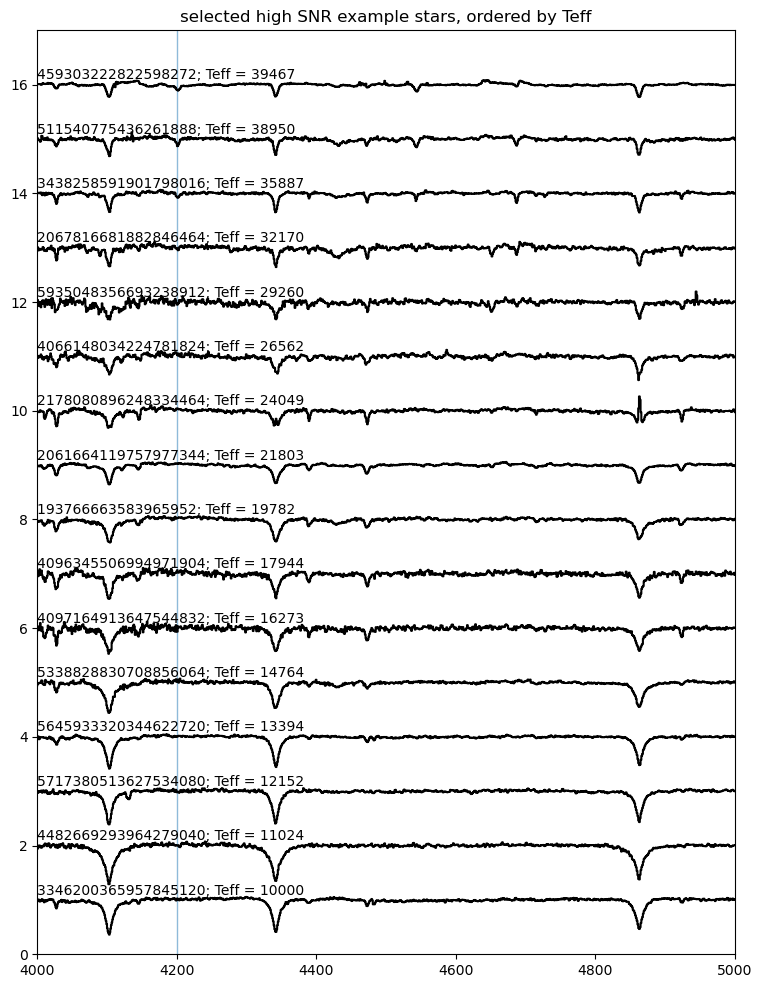

In [66]:
# make a sanity plot
tempposts = np.exp(np.linspace(np.log(np.min(spectra["Teff_fit"].to_numpy())), np.log(np.max(spectra["Teff_fit"].to_numpy())), 16))
f = plt.figure(figsize=(9, 12))
for t, T in enumerate(tempposts):
    # find closest high SNR spectrum
    highsnr = np.arange(len(spectra))[np.median(rest_ivars[:, :2000], axis=1) > 500.0]
    ii = np.argmin(np.abs(spectra["Teff_fit"].to_numpy()[highsnr] - T))
    ii = highsnr[ii]
    Teff = spectra["Teff_fit"].iloc[ii]
    print(t, T, ii, Teff)
    # plot it
    plt.step(10. ** loglam, rest_fluxes[ii] + t, c="k", where="mid")
    gid = spectra["GAIA_ID"].iloc[ii]
    label = f"{gid}; Teff = {Teff:5.0f}"
    plt.text(4000., 1.1 + t, label)
plt.ylim(0., len(tempposts) + 1.)
plt.xlim(4000, 5000)
plt.axvline(HE_II_4200, lw=1, alpha=0.5, zorder=-10)
plt.title("selected high SNR example stars, ordered by Teff")

In [54]:
assert False

AssertionError: 

## masking based on ew and temp constraints

In [ ]:
def apply_ew_mask(pickle_data, ew_limit = 0):
    
    fluxes, loglam, ivars, continuua, spec_files, rvs, ews_halphas, nana_hash, parent_spectra = pickle_data
    good_ew_mask = ews_halphas >= ew_limit

    print(f"Keeping {good_ew_mask.sum()} / {len(good_ew_mask)} spectra (removed {(~good_ew_mask).sum()} with negative EW)")

    print(nana_hash.shape)
    
    return (fluxes[good_ew_mask], ivars[good_ew_mask], continuua[good_ew_mask], rvs[good_ew_mask], ews_halphas[good_ew_mask], 
           nana_hash[good_ew_mask],[sf for sf, keep in zip(spec_files, good_ew_mask) if keep], parent_spectra[good_ew_mask])

#take a few examples
def get_temp_mask(parent_spectra_df, stars_df, temp_cut):
    gaia_ids = set(stars_df.loc[stars_df['Teff_fit'] >= temp_cut, 'GAIA_ID'])
    temp_mask = parent_spectra_df['GAIA_ID'].isin(gaia_ids).values
    print(f"Keeping {temp_mask.sum()} / {len(temp_mask)} spectra (removed {(~temp_mask).sum()} from temp cut of {temp_cut})")
    return temp_mask

#def get_specfile_from_gaia_id(gaia_id, spectra_df):
#    specfile = stars_df.loc[spectra_df['GAIA_ID'

def apply_ew_mask(flxs, loglam, ivrs, con

## get spectra data for all three cases

In [ ]:
print("FOR TEFF > 10000K:")
fluxes_10K, ivars, continuua, rvs, ews_halphas, nana_hash, spec_files, parent_spectra = apply_ew_mask(pkl_data)
print()

print("FOR TEFF > 15000K:")
mask_15K = get_temp_mask(parent_spectra, stars, temp_cut=15000)
fluxes_15K, ivars_15K, continuua_15K, rvs_15K, ews_halphas_15K, nana_hash_15K, spec_files_15K, parent_spectra_15K = (
    fluxes_10K[mask_15K], ivars[mask_15K], continuua[mask_15K], rvs[mask_15K], ews_halphas[mask_15K],
    nana_hash[mask_15K], [sf for sf, keep in zip(spec_files, mask_15K) if keep], parent_spectra[mask_15K]
)
print()

print("FOR TEFF > 25000K:")
mask_25K = get_temp_mask(parent_spectra, stars, temp_cut=25000)
fluxes_25K, ivars_25K, continuua_25K, rvs_25K, ews_halphas_25K, nana_hash_25K, spec_files_25K, parent_spectra_25K = (
    fluxes_10K[mask_25K], ivars[mask_25K], continuua[mask_25K], rvs[mask_25K], ews_halphas[mask_25K],
    nana_hash[mask_25K], [sf for sf, keep in zip(spec_files, mask_25K) if keep], parent_spectra[mask_25K]
)

In [ ]:
print("Shapes of spectra data for Teff > 15000K:")
print(f'fluxes = {fluxes_15K.shape}, ivars = {ivars_15K.shape}, continuua = {continuua_15K.shape}, spec_file = {len(spec_files_15K)}, rvs = {rvs_15K.shape}, ews_halphas = {ews_halphas_15K.shape}, nana_hash = {nana_hash_15K.shape}, parent_spectra = {parent_spectra_15K.shape}')
print()
print("Shapes of spectra data for Teff > 25000K:")
print(f'fluxes = {fluxes_25K.shape}, ivars = {ivars_25K.shape}, continuua = {continuua_25K.shape}, spec_file = {len(spec_files_25K)}, rvs = {rvs_25K.shape}, ews_halphas = {ews_halphas_25K.shape}, nana_hash = {nana_hash_25K.shape}, parent_spectra = {parent_spectra_25K.shape}')

In [ ]:
delta_log_lambda_pixel = get_delta_log_lam(loglam)

## pixel shift for the three cases

In [ ]:
rest_fluxes_10K, rest_ivars_10K, rest_continuua_10K = pixel_shift(fluxes_10K, ivars, continuua, rvs, loglam)
rest_fluxes_15K, rest_ivars_15K, rest_continuua_15K = pixel_shift(fluxes_15K, ivars_15K, continuua_15K, rvs_15K, loglam)
rest_fluxes_25K, rest_ivars_25K, rest_continuua_25K = pixel_shift(fluxes_25K, ivars_25K, continuua_25K, rvs_25K, loglam)

print(rest_fluxes_10K.shape, rest_fluxes_15K.shape, rest_fluxes_25K.shape)

In [ ]:
def fix_nans_and_infinites(rest_flxs, rest_ivrs):

    #fix nans and infinities
    bad = np.logical_not(np.isfinite(rest_flxs))
    rest_flxs[bad] = 1
    rest_ivrs[bad] = 0
    
    bad = np.logical_not(np.isfinite(rest_ivrs))
    rest_flxs[bad] = 1
    rest_ivrs[bad] = 0
    
    bad = np.logical_or((rest_flxs > 2.0), (rest_flxs < 0))
    rest_flxs[bad] = 1
    rest_ivrs[bad] = 0
    
    bad = rest_ivrs > MAX_IVAR
    # rest_fluxes[bad] = 1
    # rest_ivars[bad] = 0
    rest_ivrs[bad] = MAX_IVAR
    
    bad = rest_ivrs < MIN_IVAR
    rest_flxs[bad] = 1.0
    rest_ivrs[bad] = MIN_IVAR

    return rest_flxs, rest_ivrs

## fix nan and infinites for all three cases

In [ ]:
data_10K, weights_10K = fix_nans_and_infinites(rest_fluxes_10K, rest_ivars_10K)
data_15K, weights_15K = fix_nans_and_infinites(rest_fluxes_15K, rest_ivars_15K)
data_25K, weights_25K = fix_nans_and_infinites(rest_fluxes_25K, rest_ivars_25K)

print(data_10K.shape, data_15K.shape, data_25K.shape)

In [ ]:
# split data to A and B using nana_hash parity, only train on A
def split_and_train(rest_flxs, rest_ivrs, n_hash, K = 12, scale = 1, nu = 1):
    
    N, M = rest_flxs.shape
    
    Ainx = np.where(n_hash % 2 == 0)[0]
    Binx = np.where(n_hash % 2 == 1)[0]

    print(f"A: {len(Ainx)} spectra, B: {len(Binx)} spectra")

    modA = Robusta(rank=K, robust=True, robust_scale = scale, robust_nu = nu)
    start = time.perf_counter()
    modA.fit(rest_flxs[Ainx], rest_ivrs[Ainx], max_iter=10000)
    end = time.perf_counter()
    print("total time:", (end - start)/60, "minutes")

    return modA, Ainx, Binx    

### split and train Teff > 25000K case

In [ ]:
modelA_25K, Aindx_25K, Bindx_25K = split_and_train(data_25K, weights_25K, nana_hash_25K)

### split and train 25000K > Teff > 15000K case

In [ ]:
modelA_15K, Aindx_15K, Bindx_15K = split_and_train(data_15K, weights_15K, nana_hash_15K)

### split and train Teff > 10000K case

In [ ]:
modelA_10K, Aindx_10K, Bindx_10K = split_and_train(data_10K, weights_10K, nana_hash)

In [ ]:
def censor_and_synthesize(lines, log_lambdas, rest_flxes, rest_ivrs, Binx, modA):

    log_lines = np.log10(lines)
    
    log_H_ALPHA, log_H_BETA = log_lines[0], log_lines[1]
    log_HE_I, log_HE_II = log_lines[2], log_lines[3]
    
    region_alpha = np.abs(log_lambdas - log_H_ALPHA)
    region_beta = np.abs(log_lambdas - log_H_BETA)
    
    region_he_i = np.abs(log_lambdas - log_HE_I)
    region_he_ii = np.abs(log_lambdas - log_HE_II)
    
    censor_mask = np.ones_like(log_lambdas)
    censor_mask[(region_alpha < H_delta_loglam_line) | (region_beta < H_delta_loglam_line) 
              | (region_he_i < HE_delta_loglam_line) | (region_he_ii < HE_delta_loglam_line)] = 0 #?
    
    state, _ = modA.infer(rest_flxes[Binx], rest_ivrs[Binx] * censor_mask[None, :])
    synth_B = modA.synthesize(state)

    return state, synth_B

In [ ]:
#get synthesized spectra
state_10K, synth_B_10K = censor_and_synthesize(lines, loglam, data_10K, weights_10K, Bindx_10K, modelA_10K)

state_15K, synth_B_15K = censor_and_synthesize(lines, loglam, data_15K, weights_15K, Bindx_15K, modelA_15K)

state_25K, synth_B_25K = censor_and_synthesize(lines, loglam, data_25K, weights_25K, Bindx_25K, modelA_25K)

In [ ]:
def get_moment_vals(log_lambda, rest_flxes, rest_ivars, Binx, synthB):
    
    delta_log_lambda_pixel = get_delta_log_lam(log_lambda)
    N, M = rest_flxes[Binx].shape


    lam = 10 ** log_lambda

    exponents = np.arange(5)
    moments = np.zeros((N, len(lines), len(exponents))) + np.nan
    moment_errs = np.zeros((N, len(lines), len(exponents))) + np.nan

    for j, (line, wid) in enumerate(zip(lines, half_wids)):
        logline = np.log10(line)
        integration_weight = delta_log_lambda_pixel * LN10 * lam * (np.abs(logline - log_lambda) < wid)
        resid = rest_flxes[Binx] - synthB
        diff = lam - line #this is hogg's lam-lam0 he wrote about
    
        #compute vals and corresponding errors
        for k, expo in enumerate(exponents):
            something = integration_weight * diff ** expo
            moments[:, j, k] = np.sum(resid * something[None, :], axis=1)
            moment_errs[:, j, k] = np.sqrt(np.sum(something[None, :] ** 2 / rest_ivars[Binx], axis=1))

    return moments, moment_errs

### get moments and errors for all three cases

In [ ]:
moments_10K, moment_errs_10K = get_moment_vals(loglam, data_10K, weights_10K, Bindx_10K, synth_B_10K)
moments_15K, moment_errs_15K = get_moment_vals(loglam, data_15K, weights_15K, Bindx_15K, synth_B_15K)
moments_25K, moment_errs_25K = get_moment_vals(loglam, data_25K, weights_25K, Bindx_25K, synth_B_25K)

In [ ]:
#sort the synthesized 
foo25 = np.argsort(moments_25K[:,0, 0] / moment_errs_25K[:, 0, 0])[::-1]
f = plt.figure(figsize=(10, 8))
offset = 0.5
wave = 10 ** loglam
for i in range(12):
    f.gca().plot(wave, data_25K[Bindx_25K[foo25[i]]] + i * offset - synth_B_25K[foo25[i]], color="k")

plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="b", label = "halpha")
plt.axvline(H_BETA, lw=1, alpha=0.5, color="green", label = "hbeta")
plt.xlabel("Wavelength (angstrom)")
#plt.xlim(H_ALPHA - 200., H_ALPHA + 200.)
#plt.xlim(HE_I - 200, HE_I + 200)
plt.xlim(4000, 5000)
plt.axvline(HE_I, label = "He_I", color = "orange")
plt.legend()
halpha_lo = 10**(log_H_ALPHA - H_delta_loglam_line)
halpha_hi = 10**(log_H_ALPHA + H_delta_loglam_line)
plt.axvspan(halpha_lo, halpha_hi, color='royalblue', alpha=0.3)
hbeta_lo = 10**(log_H_BETA - H_delta_loglam_line)
hbeta_hi = 10**(log_H_BETA + H_delta_loglam_line)
plt.axvspan(hbeta_lo, hbeta_hi, color='royalblue', alpha=0.3)
plt.title("Residual at He_I for Teff > 25000, sorted by highest SNR")
plt.savefig("resid_halpha.png")
plt.show()
plt.close()

# look at a few spectra and syntheses
foo10 = np.argsort(moments_10K[:,0, 0] / moment_errs_10K[:, 0, 0])[::-1]
f = plt.figure(figsize=(10, 8))
offset = 0.5
wave = 10 ** loglam
for i in range(12):
    f.gca().plot(wave, data_10K[Bindx_10K[foo10[i]]] + i * offset - synth_B_10K[foo10[i]], color="k")

plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="b", label = "halpha")
plt.axvline(H_BETA, lw=1, alpha=0.5, color="green", label = "hbeta")
plt.xlabel("Wavelength (angstrom)")
plt.legend()
plt.xlim(H_ALPHA - 200., H_ALPHA + 200.)
halpha_lo = 10**(log_H_ALPHA - H_delta_loglam_line)
halpha_hi = 10**(log_H_ALPHA + H_delta_loglam_line)
plt.axvspan(halpha_lo, halpha_hi, color='royalblue', alpha=0.3)
hbeta_lo = 10**(log_H_BETA - H_delta_loglam_line)
hbeta_hi = 10**(log_H_BETA + H_delta_loglam_line)
plt.axvspan(hbeta_lo, hbeta_hi, color='royalblue', alpha=0.3)
plt.title("Residual at Halpha for Teff > 10000K sorted by lowest SNR")
#plt.savefig("resid_halpha.png")
plt.show()
plt.close()

In [ ]:
### functions for graphing
def plot_eigenspectra(modA, log_lambda, K = 12):
    eigsA = modA.basis_vectors().T
    wave = 10 ** log_lambda

    f = plt.figure(figsize=(15, 15))
    plt.title("Eigenspectra")
    offset = 0.2
    for i in range(K):
        f.gca().plot(wave, eigsA[i] + i * offset)
    
    #plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="blue")
    plt.xlabel("Wavelength (angstrom)")
    plt.show()
    plt.close()


def plot_synthesized_best(synthB, rest_fluxes, Binx, log_lambda, moments, moment_errs, lines, temp, K = 12):
    foo = np.argsort(moments[:,0, 0] / moment_errs[:, 0, 0])[::-1] # descending = best/most significant first
    f = plt.figure(figsize=(17, 12))
    wave = 10 ** log_lambda

    offset = 0.5
    for i in range(K):
        f.gca().plot(wave, rest_fluxes[Binx[foo[i]]] + i * offset, color="k")
        f.gca().plot(wave, synthB[foo[i]] + i * offset, color="r")

    for i, line in enumerate(lines_balmer):
        if i == 0: 
            plt.axvline(line, lw=1, alpha=0.5, color="royalblue", label = "balmer")
        else:
            plt.axvline(line, lw=1, alpha=0.5, color="royalblue")

    for i, line in enumerate(lines_HE_I):
        if i == 0: 
            plt.axvline(line, lw=1, alpha=0.5, color="hotpink", label = "HE I")
        else:
            plt.axvline(line, lw=1, alpha=0.5, color="hotpink")

    for i, line in enumerate(lines_HE_II):
        if i == 0: 
            plt.axvline(line, lw=1, alpha=0.5, color="green", label = "HE II")
        else:
            plt.axvline(line, lw=1, alpha=0.5, color="green")
            
    plt.xlim(4500, 5000)
    plt.xlabel("Wavelength (angstrom)")
    plt.legend()
    halpha_lo = 10**(log_H_ALPHA - H_delta_loglam_line)
    halpha_hi = 10**(log_H_ALPHA + H_delta_loglam_line)
    plt.axvspan(halpha_lo, halpha_hi, color='royalblue', alpha=0.3)
    if temp == 25:
        plt.title("Lowest signal to noise synthesized spectra with Teff > 25000K")
    if temp == 15:
        plt.title("Lowest signal to noise synthesized spectra with 15000 < Teff < 25000K")
    if temp == 10:
        plt.title("Lowest signal to noise synthesized spectra with Teff > 10000K")
    plt.show()
   
    plt.close()


In [ ]:
plot_synthesized_best(synth_B_25K, data_25K, Bindx_25K, loglam, moments_25K, moment_errs_25K, lines, temp = 25)
plot_synthesized_best(synth_B_15K, data_15K, Bindx_15K, loglam, moments_15K, moment_errs_15K, lines, temp = 15)
plot_synthesized_best(synth_B_10K, data_10K, Bindx_10K, loglam, moments_10K, moment_errs_10K, lines, temp = 10)

## Bindx_tuple = Bindx_10K, Bindx_15K, Bindx_25K 
synth_B_tuple = synth_B_10K, synth_B_15K, synth_B_25K 
all_spec_files_tuple = spec_files, spec_files_15K, spec_files_25K

rest_fluxes_tuple = rest_fluxes_10K, rest_fluxes_15K, rest_fluxes_25K
rest_continuua_tuple = rest_continuua_10K, rest_continuua_15K, rest_continuua_25K

data_tuple = data_10K, data_15K, data_25K

In [ ]:
def plot_synthesized_by_fits(fits_name, fluxes, temp_cut, spec_files, loglam, synth, Binx, lines, offset=0.0):
    
    pos = spec_files.index(fits_name)
    teff, gaia_id = get_teff_from_fits(fits_name, spectra, stars)
    print("this spectra is from star with teff and gaia_id" , teff, gaia_id)


    b_matches = np.where(Binx == pos)[0]
    if len(b_matches) == 0:
        raise ValueError(f"'{fits_name}' is not in the B partition — no synthesized spectrum available.")
    b_i = b_matches[0]

   
    rest_flux = fluxes[pos]
    wave = 10 ** loglam
    print()
    print("rest flux shape:", rest_flux.shape, "synthB shape:", synth.shape)
    f = plt.figure(figsize=(15, 6))
    f.gca().plot(wave, rest_flux + offset, color="k", label="observed")
    f.gca().plot(wave, synth[b_i] + offset, color="r", label="synthesized")

    log_H_ALPHA, log_H_BETA, log_HE_I, log_HE_II = np.log10(H_ALPHA), np.log10(H_BETA), np.log10(HE_I), np.log10(HE_II)


    for i, line in enumerate(lines_balmer):
        if i == 0: 
            plt.axvline(line, lw=1, alpha=0.5, color="b", label = "balmer")
        else:
            plt.axvline(line, lw=1, alpha=0.5, color="b")

    for i, line in enumerate(lines_HE_I):
        if i == 0: 
            plt.axvline(line, lw=1, alpha=0.5, color="hotpink", label = "HE I")
        else:
            plt.axvline(line, lw=1, alpha=0.5, color="hotpink")

    for i, line in enumerate(lines_HE_II):
        if i == 0: 
            plt.axvline(line, lw=1, alpha=0.5, color="green", label = "HE II")
        else:
            plt.axvline(line, lw=1, alpha=0.5, color="green")



    #plt.xlim(4200, 7000)
    plt.xlabel("Wavelength (angstrom)")
    #change here
    plt.xlim(4500, 5000) 
    #plt.xlim(6500, 6800)
    #plt.xlim(3800, 4500)
    #plt.xlim(7000,9000)
    plt.ylim(0.1,2)
    halpha_lo = 10**(log_H_ALPHA - H_delta_loglam_line)
    halpha_hi = 10**(log_H_ALPHA + H_delta_loglam_line)
    plt.axvspan(halpha_lo, halpha_hi, color='royalblue', alpha=0.3)
    if temp_cut < 15000:
        plt.title(f'Synthesized spectra in {temp_cut} < Teff <= 15000 region: {fits_name} with Teff = {teff:.0f}')

    elif 15000 <= temp_cut < 25000:
        plt.title(f'Synthesized spectra in {temp_cut} < Teff <= 25000 region: {fits_name} with Teff = {teff:.0f}')


    elif temp_cut >= 25000:
        plt.title(f'Synthesized spectra in {temp_cut} < Teff region: {fits_name} with Teff = {teff:.0f} gaia id = {gaia_id}')
    
    plt.legend()
    plt.show()
    plt.close()

In [ ]:
def get_specfiles_from_temp2(temp_cut, stars_df, spectra_df, Binxs, all_spec_files_tuple, synthBs, lines, plot = False):

    Bindx_10K, Bindx_15K, Bindx_25K = Binxs
    synth_B_10K, synth_B_15K, synth_B_25K = synthBs
    spec_files, spec_files_15K, spec_files_25K = all_spec_files_tuple
    
    if 10000 <= temp_cut < 15000:
        mask_ids = stars_df.loc[(stars_df['Teff_fit'] >= temp_cut) & (stars_df['Teff_fit'] < 15000), 'GAIA_ID']
        Binx, synthB, all_spec_files, fluxes = Bindx_10K, synth_B_10K, spec_files, fluxes_10K
        print("using model for 10K")
        print(f"{len(mask_ids)} stars {temp_cut} < Teff < 15000K")

    elif 15000 <= temp_cut < 25000:
        mask_ids = stars_df.loc[(stars_df['Teff_fit'] >= temp_cut) & (stars_df['Teff_fit'] < 25000), 'GAIA_ID']
        print(f"{len(mask_ids)} stars {temp_cut} < Teff < 25000K")
        print("using model for 15K =< Teff < 25K")
        Binx, synthB, all_spec_files, fluxes = Bindx_15K, synth_B_15K, spec_files_15K, fluxes_15K


    elif temp_cut >= 25000:
        mask_ids = stars_df.loc[(stars_df['Teff_fit'] >= temp_cut), 'GAIA_ID']
        print(f"{len(mask_ids)} stars {temp_cut}K <= Teff ")
        print("using model for Teff > =25000")
        Binx, synthB, all_spec_files, fluxes = Bindx_25K, synth_B_25K, spec_files_25K, fluxes_25K

    else:
        print("something went wrong")

    # match gaia ids with the star parquet to the spectra partquet, and get fits file name
    mask_spectra = spectra_df['GAIA_ID'].isin(mask_ids)
    spec_files = spectra_df.loc[mask_spectra, 'SPEC_FILE'].tolist()
    
    print(f"{len(spec_files)} spectra belong to temp cut")

    pos_lookup = {f: i for i, f in enumerate(all_spec_files)}
    synthB_spec_loc = []
    for spec in spec_files:
        pos = pos_lookup.get(spec)
        if pos is not None:
            synthB_spec_loc.append(pos)
    #print(f'{len(synthB_spec_loc)} spec that meet temp cut in synthB')

    binx_set = set(Binx)
    spec_in_B = [p for p in synthB_spec_loc if p in binx_set]
    print(f'{len(spec_in_B)} of those are in partition B (have synthB)')

    if plot == True:
        if spec_in_B:
            example_pos = spec_in_B[1]
            example_fits = all_spec_files[example_pos]
            print(f"Plotting example: {example_fits}")
            print(synthB.shape, Binx.shape, fluxes.shape)
            plot_synthesized_by_fits(example_fits, fluxes, temp_cut, all_spec_files, loglam, synthB, Binx, lines)


    return spec_in_B

In [ ]:
spec_in_B = get_specfiles_from_temp2(25000, stars, spectra, Bindx_tuple, all_spec_files_tuple, synth_B_tuple, lines, plot=True)

In [ ]:
def get_teff_from_fits(fits_name, spectra_df, stars_df):
    match = spectra_df.loc[spectra_df['SPEC_FILE'] == fits_name, 'GAIA_ID']
    if match.empty:
        raise ValueError(f"'{fits_name}' not found in spectra_df")
    gaia_id = match.iloc[0]

    star_match = stars_df.loc[stars_df['GAIA_ID'] == gaia_id, 'Teff_fit']
    if star_match.empty:
        raise ValueError(f"GAIA_ID {gaia_id} (from '{fits_name}') not found in stars_df")

    return star_match.iloc[0], gaia_id